# Assignment: House-price prediction with heterogeneous neighborhoods

In the linear-regression lecture you fit a single linear model to noisy samples of a single underlying function. Real-world datasets are rarely that clean. A common reason a "perfectly reasonable" linear model fails is that the data secretly comes from *two or more distinct generating processes*, and a single model averages over them.

In this assignment you will:

1. **Generate** a synthetic house-price dataset where the houses live in **two spatial clusters** (a rich and a poor neighborhood), and the price-vs-features relationship is **different in each neighborhood**.
2. **Visualize** the clusters in space and price-vs-square-footage.
3. **Fit two competing models**:
   - a single linear regression on all houses;
   - one linear regression *per neighborhood*.
4. **Compare** them and explain why one wins.

The point is not to predict house prices well. The point is to see what a single linear model loses when it averages over heterogeneous subgroups.


## Recap: connection to the linear-regression lecture

| Lecture | This assignment |
|---|---|
| Hypothesis $g(\mathbf{w}, \mathbf{x}) = \mathbf{w}^T \boldsymbol{\phi}(\mathbf{x})$ | Same hypothesis class. Features are $(x, y, \text{sqft}, \text{num\_bedrooms}, \text{num\_bathrooms})$. |
| MSE loss $L(\mathbf{w}) = \frac{1}{m}\sum_i (g(\mathbf{w}, x_i) - y_i)^2$ | Same loss, minimized by `sklearn.LinearRegression`. |
| One underlying target function $\sin(2\pi x)$ | **Two** underlying target functions, one per neighborhood. This is the new ingredient. |
| Overfitting controlled by model capacity ($M$) and shrinkage ($\lambda$) | Mismatch here comes from *under-modeling* (one model for two regimes), not from over-capacity. The fix is not a richer basis; it is a richer *conditioning structure*. |

What is **new**:

- The data is **heterogeneous**: two subgroups with different parameters generating the target. A single linear hypothesis cannot represent both.
- The choice of whether to fit one model or many is itself a modeling decision, parallel to the choice of basis function in the lecture and to the choice of target parameterization in the box-regression assignment.


## Dataset specification

You will write a generator function that produces $N$ houses split into two neighborhoods. Each house has the columns:

| Column | Type | Meaning |
|---|---|---|
| `x` | `float` | east-west coordinate, in [0, 100] |
| `y` | `float` | north-south coordinate, in [0, 100] |
| `sqft` | `float` | living area in square feet |
| `num_bedrooms` | `int` | integer, $\ge 1$ |
| `num_bathrooms` | `int` | integer, $\ge 1$ |
| `neighborhood` | `str` in `{"rich", "poor"}` | which subgroup the house belongs to |
| `price` | `float` | the target the regressor will try to predict, in US dollars |

The generator must satisfy these requirements:

**Spatial clusters**
- Rich houses are clustered around $(\mu_x^r, \mu_y^r) = (75, 75)$ with standard deviation $\sigma_{xy}^r = 6$.
- Poor houses are clustered around $(\mu_x^p, \mu_y^p) = (25, 25)$ with standard deviation $\sigma_{xy}^p = 8$.
- 40% of houses are in the rich neighborhood, 60% in the poor neighborhood.

**Per-house features**
- *Rich neighborhood:* `sqft` $\sim$ Uniform$(1800, 4500)$.
- *Poor neighborhood:* `sqft` $\sim$ Uniform$(800, 2000)$.
- `num_bedrooms` $=$ `clip(round(sqft / 600 + N(0, 0.3)), 1, 6)` for every house, regardless of neighborhood. This is a deterministic function of `sqft` plus integer rounding noise. The same rule applies in both neighborhoods.
- `num_bathrooms` $=$ `clip(round(num_bedrooms / 1.5 + N(0, 0.4)), 1, 5)`. Same rule in both neighborhoods.

**Target (price) — different in each neighborhood**
- Rich neighborhood:
  $$ \text{price} = 350 \cdot \text{sqft} + 30{,}000 \cdot \text{num\_bedrooms} + 50{,}000 \cdot \text{num\_bathrooms} + 100{,}000 + \varepsilon^r $$
  with $\varepsilon^r \sim \mathcal{N}(0, 30{,}000^2)$.
- Poor neighborhood:
  $$ \text{price} = 120 \cdot \text{sqft} + 8{,}000 \cdot \text{num\_bedrooms} + 15{,}000 \cdot \text{num\_bathrooms} + 30{,}000 + \varepsilon^p $$
  with $\varepsilon^p \sim \mathcal{N}(0, 15{,}000^2)$.

Note the price-per-square-foot is ~$\$350$ in the rich neighborhood and only ~$\$120$ in the poor neighborhood. That structural difference is the heterogeneity you are studying.

Use a seeded random generator so your dataset is reproducible.


In [ ]:
# Required packages:
# pip install numpy pandas matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

RNG_SEED = 42


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 38.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 40.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 40.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 36.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 37.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 36.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 41.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [matplotlib]4 [matplotlib]n]

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Task 1 — Generate the dataset

Implement the function `generate_houses(n_total=2000, rich_fraction=0.4, seed=RNG_SEED)` to follow the specification above. Each `# TODO` marker is something you must fill in. The structure of the function is given so you do not have to redesign the API.

The function must return a `pandas.DataFrame` with the seven columns from the spec, in any row order.


In [5]:
def generate_houses(n_total=2000, rich_fraction=0.4, seed=RNG_SEED):
    rng = np.random.default_rng(seed)

    n_rich = int(round(n_total * rich_fraction))
    n_poor = n_total - n_rich

    # --- Spatial coordinates ---------------------------------------------------
    # TODO: sample n_rich (x, y) pairs from a 2-D Gaussian centered at (75, 75)
    #       with std 6 on each axis. Hint: rng.normal(loc=..., scale=..., size=...).
    rich_x = rng.normal(loc=75, scale=6, size=n_rich)
    rich_y = rng.normal(loc=75, scale=6, size=n_rich)

    # TODO: sample n_poor (x, y) pairs from a 2-D Gaussian centered at (25, 25)
    #       with std 8 on each axis.
    poor_x = rng.normal(loc=25, scale=8, size=n_poor)
    poor_y = rng.normal(loc=25, scale=8, size=n_poor)

    # --- Square footage --------------------------------------------------------
    # TODO: rich sqft uniform in [1800, 4500]; poor sqft uniform in [800, 2000].
    rich_sqft = np.random.uniform(1800, 4500, size=n_rich)
    poor_sqft = np.random.uniform(800, 2000, size=n_poor)

    # --- Build per-row records and stack --------------------------------------
    rich = pd.DataFrame({
        "x": rich_x,
        "y": rich_y,
        "sqft": rich_sqft,
        "neighborhood": "rich",
    })
    poor = pd.DataFrame({
        "x": poor_x,
        "y": poor_y,
        "sqft": poor_sqft,
        "neighborhood": "poor",
    })
    df = pd.concat([rich, poor], ignore_index=True)

    # --- Bedrooms and bathrooms (same rule in both neighborhoods) -------------
    # TODO: num_bedrooms = clip(round(sqft / 600 + N(0, 0.3)), 1, 6).
    # TODO: num_bathrooms = clip(round(num_bedrooms / 1.5 + N(0, 0.4)), 1, 5).
    df["num_bedrooms"] = np.clip(np.round(df["sqft"] / 600 + rng.normal(0, 0.3, size=len(df))), 1, 6).astype(int)
    df["num_bathrooms"] = np.clip(np.round(df["num_bedrooms"] / 1.5 + rng.normal(0, 0.4, size=len(df))), 1, 5).astype(int)

    # --- Price (different per neighborhood) -----------------------------------
    # TODO: compute price per the rich/poor formulas in the spec and add noise.
    # Hint: use np.where(df.neighborhood == "rich", price_rich, price_poor).
    price_rich = 350 * df["sqft"] + 30000 * df["num_bedrooms"] + 50000 * df["num_bathrooms"] + 100000 + rng.normal(0, 30000, size=len(df))
    price_poor = 120 * df["sqft"] + 8000 * df["num_bedrooms"] + 15000 * df["num_bathrooms"] + 30000 + rng.normal(0, 15000, size=len(df))
    df["price"] = np.where(df["neighborhood"] == "rich", price_rich, price_poor)

    # Shuffle so the rich/poor rows are interleaved.
    df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    return df


houses = generate_houses()
print(houses.head())
print(f"\\nshape: {houses.shape}")
print(houses["neighborhood"].value_counts())


           x          y         sqft neighborhood  num_bedrooms  \
0  16.933529  15.282653  1317.127902         poor             3   
1  79.882582  71.631102  3959.026881         rich             6   
2  27.592714  21.820133   885.304011         poor             2   
3  40.223260  25.329440  1001.242450         poor             2   
4  28.742558  16.771966  1203.169993         poor             3   

   num_bathrooms         price  
0              2  2.166589e+05  
1              4  1.827631e+06  
2              2  1.828262e+05  
3              2  1.837821e+05  
4              2  2.039412e+05  
\nshape: (2000, 7)
neighborhood
poor    1200
rich     800
Name: count, dtype: int64


### Self-check

If your generator is correct, the assertions below should all pass. Use them to debug your `Task 1` implementation before moving on.


In [6]:
def check_dataset(df):
    assert set(df.columns) >= {"x", "y", "sqft", "num_bedrooms", "num_bathrooms", "neighborhood", "price"}, \
        "missing expected columns"
    assert df["neighborhood"].isin(["rich", "poor"]).all(), "neighborhood must be 'rich' or 'poor'"
    assert df["num_bedrooms"].between(1, 6).all() and df["num_bedrooms"].dtype.kind in "iu", \
        "num_bedrooms must be integer in [1, 6]"
    assert df["num_bathrooms"].between(1, 5).all() and df["num_bathrooms"].dtype.kind in "iu", \
        "num_bathrooms must be integer in [1, 5]"

    rich = df[df.neighborhood == "rich"]
    poor = df[df.neighborhood == "poor"]
    assert 1700 <= rich["sqft"].min() and rich["sqft"].max() <= 4600, "rich sqft range wrong"
    assert 700 <= poor["sqft"].min() and poor["sqft"].max() <= 2100, "poor sqft range wrong"

    # Rich-cluster center should be near (75, 75); poor near (25, 25).
    assert abs(rich[["x", "y"]].mean().mean() - 75) < 2, "rich cluster not centered at ~75"
    assert abs(poor[["x", "y"]].mean().mean() - 25) < 2, "poor cluster not centered at ~25"

    # Rich houses should cost more per sqft on average.
    rich_pps = (rich["price"] / rich["sqft"]).mean()
    poor_pps = (poor["price"] / poor["sqft"]).mean()
    assert rich_pps > 2 * poor_pps, f"rich $/sqft ({rich_pps:.0f}) should be >> poor ({poor_pps:.0f})"

    print("all checks passed")
    print(f"  rich $/sqft (avg): {rich_pps:>8.0f}")
    print(f"  poor $/sqft (avg): {poor_pps:>8.0f}")


check_dataset(houses)


all checks passed
  rich $/sqft (avg):      486
  poor $/sqft (avg):      174


## Task 2 — Visualize the spatial clusters

Plot every house as a point in the $(x, y)$ plane, colored by neighborhood. The two clusters should pop out visually.


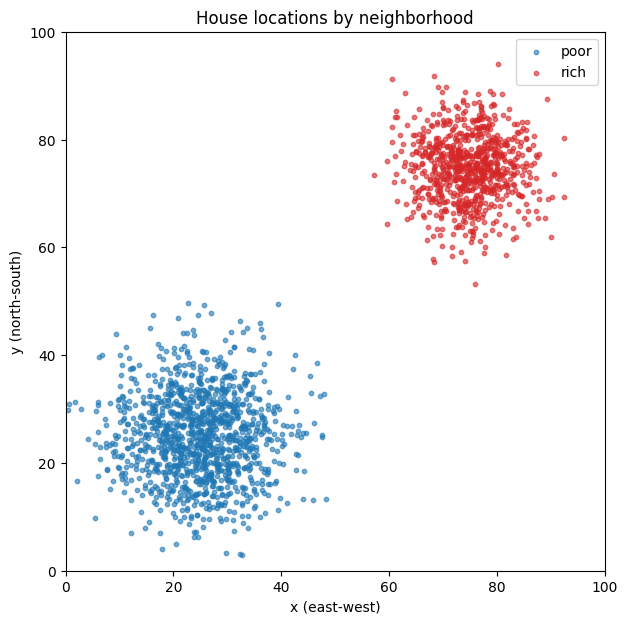

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))
for color, label in [("tab:blue", "poor"), ("tab:red", "rich")]:
    subset = houses[houses["neighborhood"] == label]
    ax.scatter(subset["x"], subset["y"], s=10, alpha=0.6, label=label, color=color)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_aspect("equal")
ax.set_xlabel("x (east-west)")
ax.set_ylabel("y (north-south)")
ax.set_title("House locations by neighborhood")
ax.legend()
plt.show()


## Task 3 — Visualize price vs square footage per neighborhood

Plot `price` against `sqft`, colored by neighborhood. You should see two distinct linear trends with different slopes. That visual difference is exactly what a single linear model cannot capture.


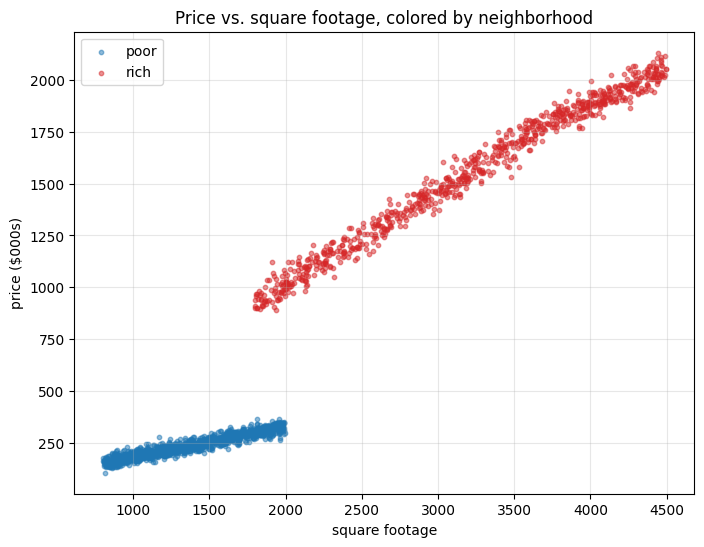

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
for color, label in [("tab:blue", "poor"), ("tab:red", "rich")]:
    subset = houses[houses["neighborhood"] == label]
    ax.scatter(subset["sqft"], subset["price"] / 1000, s=10, alpha=0.5, label=label, color=color)
ax.set_xlabel("square footage")
ax.set_ylabel("price ($000s)")
ax.set_title("Price vs. square footage, colored by neighborhood")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


## Task 4 — Fit one global linear regression

Fit a single linear regression on all the houses, using the numeric features only (no `neighborhood` column yet).


In [9]:
FEATURES = ["x", "y", "sqft", "num_bedrooms", "num_bathrooms"]

X = houses[FEATURES].to_numpy()
y = houses["price"].to_numpy()
neigh = houses["neighborhood"].to_numpy()

X_train, X_test, y_train, y_test, neigh_train, neigh_test = train_test_split(
    X, y, neigh, test_size=0.25, random_state=RNG_SEED
)

global_model = LinearRegression()
global_model.fit(X_train, y_train)

y_pred = global_model.predict(X_test)
global_mse = mean_squared_error(y_test, y_pred)
global_rmse = np.sqrt(global_mse)  # RMSE is just the square root of MSE, in dollars

print(f"Global model MSE  (test): {global_mse:>18,.0f}  (dollars-squared)")
print(f"Global model RMSE (test): ${global_rmse:>15,.0f}  (dollars; sqrt of MSE)")
print()
print("Per-neighborhood test RMSE under the global model:")
for label in ["rich", "poor"]:
    mask = neigh_test == label
    rmse_label = np.sqrt(mean_squared_error(y_test[mask], y_pred[mask]))
    print(f"  {label:>4}: ${rmse_label:>10,.0f}  (n={mask.sum()})")


Global model MSE  (test):      8,403,649,151  (dollars-squared)
Global model RMSE (test): $         91,671  (dollars; sqrt of MSE)

Per-neighborhood test RMSE under the global model:
  rich: $    69,137  (n=201)
  poor: $   104,114  (n=299)


## Task 5 — Fit two per-neighborhood linear regressions

Fit one model on rich houses only and one on poor houses only. Evaluate each on its own test rows.


In [10]:
per_neighborhood_models = {}
per_neighborhood_metrics = {}

for label in ["rich", "poor"]:
    train_mask = neigh_train == label
    test_mask = neigh_test == label

    model = LinearRegression()
    model.fit(X_train[train_mask], y_train[train_mask])
    y_pred_label = model.predict(X_test[test_mask])

    mse = mean_squared_error(y_test[test_mask], y_pred_label)
    rmse = np.sqrt(mse)

    per_neighborhood_models[label] = model
    per_neighborhood_metrics[label] = {"mse": mse, "rmse": rmse, "n_test": int(test_mask.sum())}

    print(f"{label:>4} model RMSE (test): ${rmse:>10,.0f}   (n={test_mask.sum()})")

# Aggregate test MSE across the two per-neighborhood models, for an apples-to-apples
# comparison with the single global model.
y_pred_per = np.empty_like(y_test, dtype=float)
for label, model in per_neighborhood_models.items():
    mask = neigh_test == label
    y_pred_per[mask] = model.predict(X_test[mask])
combined_mse = mean_squared_error(y_test, y_pred_per)
combined_rmse = np.sqrt(combined_mse)
print(f"\nCombined per-neighborhood MSE  (test): {combined_mse:>18,.0f}")
print(f"Combined per-neighborhood RMSE (test): ${combined_rmse:>15,.0f}")


rich model RMSE (test): $    30,881   (n=201)
poor model RMSE (test): $    14,741   (n=299)

Combined per-neighborhood MSE  (test):        513,299,135
Combined per-neighborhood RMSE (test): $         22,656


## Task 6 — Compare and interpret

Fill in the table below with the numbers your cells just printed. Use **MSE** (the metric defined in the linear-regression lecture) for the comparison; we also report RMSE = $\sqrt{\text{MSE}}$ because RMSE is in the same units as the target (dollars) and is easier to read.

| Model | Test MSE | Test RMSE (\$) |
|---|---:|---:|
| One global linear regression |8,403,649,151|91,671|
| Two per-neighborhood regressions (combined) |513,299,135|22,656|
| Rich-only model on rich test rows |953,636,161|30,881|
| Poor-only model on poor test rows |217,297,081|14,741|

Then answer:

1. Which approach has the lower overall test MSE?

    The two per-neighborhood regressions approach has the lower overall test MSE.
2. Look at the per-neighborhood RMSE under the **global** model (printed at the end of Task 4). Is it the same for rich and poor, or does the global model systematically perform worse on one of the two neighborhoods? Why?

    The global model produces an RMSE for the rich neighborhood at 69,137 and an RMSE for the poor neighborhood at 104,114. This means that the model performs worse on the poor neighborhood. The poor performance goes both ways since the parameters for the price of a house for a given neighborhood will make the prediction for a house in the other neighborhood worse. However, since the rich neighborhood has a much larger constant value, costs much more per sqft, and costs much more per bedroom/bathroom, the model has to make large compromises to generalize over the two neighborhoods, all favoring the rich neighborhood. So, for the poor neighborhood specifically, this generalization hurts more because of the high prices of the features of the rich house and because the misses are a larger percentage of the price of the less expensive houses in the poor neighborhood.
3. The two-models approach trains each model on roughly half the data of the global model. Why does it still win? What is each smaller model getting in exchange for the smaller training set?

    Each smaller model, although losing data set size, has less bias towards the other neighborhood specifications. A prediction for a home with given square footage, bedrooms, and bathrooms in the poor neighborhood will not be affected by the high prices of a house with similar features in the rich neighborhood. This reduction in bias greatly makes up for the slight precision loss.
4. **Prediction for Task 7.** In the next task you will add a one-hot encoded `neighborhood` feature to the *global* model. Before you run it, predict: will adding that single binary feature close the gap with the two-models approach completely, partially, or not at all? Justify your prediction in terms of what an extra one-hot feature lets a linear model express.

    I predict that this feature will partially close the gap with the two-models approach for the global model. It will allow the two neighborhoods constant values to not affect each other as much. This fix will help create two different constant weights for the prediction based on neighborhood, but both neighborhoods still share sqft, num_bedrooms, and num_bathrooms, therefore sharing slope and still performing not as well as the two-model approach.
5. If, instead of two cleanly separated neighborhoods, the dataset had a smooth gradient (e.g., price-per-sqft varied continuously across the $(x, y)$ plane), would the two-models approach still help? What would you change?

    If the dataset had a smooth gradient, the two-models approach would not be very effective because there would not be a hard split of prices per features. A better appraoch would be to have the per-sqft slope vary with location.


## Task 7 — Add the neighborhood as a one-hot feature to the global model

In Task 6 you predicted whether adding a one-hot encoded `neighborhood` feature to the **single global** model would close the gap with the two-models approach. Now you check that prediction empirically.

Add a binary feature `is_rich` (1 if the house is in the rich neighborhood, 0 otherwise) to the feature matrix and refit a single linear regression on all the houses. Report MSE and RMSE on the same held-out test split as before, including the per-neighborhood RMSE breakdown.

Then compare three numbers side by side:

- bare global model (Task 4)
- global + one-hot model (this task)
- two-models combined (Task 5)

A linear model with a one-hot feature gains *one extra weight*. Geometrically, that weight is an additive **intercept shift** between the two neighborhoods. The model's slopes on `sqft`, `num_bedrooms`, `num_bathrooms` are still shared across both neighborhoods. Keep that in mind as you read the numbers.


In [12]:
is_rich = (neigh == "rich").astype(int).reshape(-1, 1)
X_aug = np.hstack([X, is_rich])

X_aug_train, X_aug_test, _, _, _, _ = train_test_split(
    X_aug, y, neigh, test_size=0.25, random_state=RNG_SEED
)
# Use the same y_train / y_test / neigh_train / neigh_test as before so the
# comparison is on identical rows.

onehot_model = LinearRegression()
onehot_model.fit(X_aug_train, y_train)

y_pred_onehot = onehot_model.predict(X_aug_test)
onehot_mse = mean_squared_error(y_test, y_pred_onehot)
onehot_rmse = np.sqrt(onehot_mse)

print(f"Global + one-hot model MSE  (test): {onehot_mse:>18,.0f}")
print(f"Global + one-hot model RMSE (test): ${onehot_rmse:>15,.0f}")
print()
print("Per-neighborhood test RMSE under the global + one-hot model:")
for label in ["rich", "poor"]:
    mask = neigh_test == label
    rmse_label = np.sqrt(mean_squared_error(y_test[mask], y_pred_onehot[mask]))
    print(f"  {label:>4}: ${rmse_label:>10,.0f}  (n={mask.sum()})")

print()
print("Coefficient on the new is_rich feature (intercept shift, in dollars):")
print(f"  w_is_rich = ${onehot_model.coef_[-1]:,.0f}")


Global + one-hot model MSE  (test):      5,170,297,206
Global + one-hot model RMSE (test): $         71,905

Per-neighborhood test RMSE under the global + one-hot model:
  rich: $    62,751  (n=201)
  poor: $    77,452  (n=299)

Coefficient on the new is_rich feature (intercept shift, in dollars):
  w_is_rich = $650,922


### Compare and reflect

Fill in the extended table:

| Model | Test MSE | Test RMSE (\$) |
|---|---:|---:|
| Bare global linear regression (Task 4) |8,403,649,151|91,671|
| Global + one-hot `is_rich` (Task 7) |5,170,297,206|71,905|
| Two per-neighborhood regressions (Task 5) |513,299,135|22,656|

Answer:

1. Did the one-hot fully close the gap with the two-models approach, or only partially? By how much (RMSE difference)?

    The one-hot only partially closed the gap with the two-models approach. It lowered the RMSE from 91,671 to 71,905, a difference of 19,766.
2. The coefficient on `is_rich` printed above is an **intercept shift**: it adds a fixed dollar amount to the prediction for every rich house, regardless of size or room count. Why is an intercept shift not enough to match the two-models approach in this dataset? (Hint: look back at the price formulas in the spec — what differs between rich and poor besides the constant term?)

    An intercept shift is not enough to match the two models approach because besides the constant terms in the price formulas, there are also differences in price per sqft and price per bedroom/bathroom. So, it is still compromising in the slopes between the two neighborhoods. 
3. What additional features would you have to add to the global model to make it *mathematically equivalent* to the two-models approach? You will build this next in Task 8.

    


## Task 8 — Add interaction terms to match the two-models approach exactly

In Task 7 you saw that a one-hot `is_rich` feature alone gives the global model only an **intercept shift** between neighborhoods. To let the global model also use **different slopes** per neighborhood, add interaction features:

- `is_rich * sqft`
- `is_rich * num_bedrooms`
- `is_rich * num_bathrooms`

Each interaction is a product of two existing columns. For a rich house (`is_rich = 1`) the interaction equals the second factor; for a poor house (`is_rich = 0`) it equals zero. Geometrically the model now has, for each of `sqft`, `num_bedrooms`, `num_bathrooms`, a *base* slope (used for poor houses) and a *rich-only adjustment* slope (added on top for rich houses). The same trick applies to the intercept via `is_rich` itself.

Fit a single linear regression with the augmented feature matrix and compare its RMSE to the two-models combined RMSE from Task 5. They should be effectively identical, up to the train/test-split randomness in how rows are routed between the two per-neighborhood models. The exercise lets you confirm that the two-models approach is *not* a fundamentally richer hypothesis class; it is just a convenient way to write down a model the single global regression could also represent with the right features.


In [ ]:
# Build the augmented feature matrix: original 5 features + is_rich + 3 interactions.
is_rich_col = (neigh == "rich").astype(int).reshape(-1, 1)
sqft_col = houses["sqft"].to_numpy().reshape(-1, 1)
bed_col = houses["num_bedrooms"].to_numpy().reshape(-1, 1)
bath_col = houses["num_bathrooms"].to_numpy().reshape(-1, 1)

X_inter = np.hstack([
    X,                              # x, y, sqft, num_bedrooms, num_bathrooms
    is_rich_col,                    # is_rich
    is_rich_col * sqft_col,         # interaction with sqft
    is_rich_col * bed_col,          # interaction with num_bedrooms
    is_rich_col * bath_col,         # interaction with num_bathrooms
])

X_inter_train, X_inter_test, _, _, _, _ = train_test_split(
    X_inter, y, neigh, test_size=0.25, random_state=RNG_SEED
)
# Reuse y_train, y_test, neigh_train, neigh_test from earlier tasks so the
# comparison is on identical test rows.

interaction_model = LinearRegression()
interaction_model.fit(X_inter_train, y_train)

y_pred_inter = interaction_model.predict(X_inter_test)
inter_mse = mean_squared_error(y_test, y_pred_inter)
inter_rmse = np.sqrt(inter_mse)

print(f"Global + one-hot + interactions MSE  (test): {inter_mse:>18,.0f}")
print(f"Global + one-hot + interactions RMSE (test): ${inter_rmse:>15,.0f}")
print()
print("Per-neighborhood test RMSE under the interaction-augmented global model:")
for label in ["rich", "poor"]:
    mask = neigh_test == label
    rmse_label = np.sqrt(mean_squared_error(y_test[mask], y_pred_inter[mask]))
    print(f"  {label:>4}: ${rmse_label:>10,.0f}  (n={mask.sum()})")

print()
print("Coefficients on the rich-only adjustments (added on top of the base slopes):")
print(f"  Δ slope on sqft:           {interaction_model.coef_[-3]:>10,.2f}  $/sqft")
print(f"  Δ slope on num_bedrooms:   ${interaction_model.coef_[-2]:>10,.0f}")
print(f"  Δ slope on num_bathrooms:  ${interaction_model.coef_[-1]:>10,.0f}")


### Compare to the two-models approach

Read off the new combined-test RMSE and compare it to the **two-models combined RMSE** you printed at the end of Task 5.

Answer:

1. Are the two numbers essentially equal? If so, what does that tell you about how rich a hypothesis class the two-models approach really is, compared to a single linear regression on the right feature set?
2. Look at the printed Δ slopes (the coefficients on the three interactions). Add each to the corresponding base slope (from Task 4's bare global model). Do the sums match the per-neighborhood coefficients you would see if you printed `per_neighborhood_models["rich"].coef_` and `per_neighborhood_models["poor"].coef_`?
3. Both Task 5 (two models) and Task 8 (one augmented model) have the same number of free parameters. Count them and confirm.
